# 💰 Day 25 - Loan Default Prediction using Gradient Boosting
### Predicting borrower delinquency risk using financial and demographic features

In [1]:
# give_me_some_credit_full_pipeline.py
# Clean linear pipeline for 'Give Me Some Credit' dataset (fast, production-aware)
# Requirements: pandas, numpy, scikit-learn, lightgbm, shap, joblib, matplotlib
# Install: pip install pandas numpy scikit-learn lightgbm shap joblib matplotlib

import os, warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve, auc, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

import lightgbm as lgb
import joblib

In [2]:
# -------------------------
# 0) Config / file path
# -------------------------
DATA_CSV = "cs-training.csv"   # <<-- change to where you downloaded cs-training.csv
MODEL_OUT = Path("models/give_credit_lgbm.joblib")

# -------------------------
# 1) Load
# -------------------------
print("Loading dataset...")
df = pd.read_csv(DATA_CSV)
# Kaggle file has an unnamed index column; drop if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
print("Shape:", df.shape)
print(df.head(3))
print()

Loading dataset...
Shape: (150000, 11)
   SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0                 1                              0.766127   45   
1                 0                              0.957151   40   
2                 0                              0.658180   38   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                        0   
1                                4                        0   
2                                2                        1   

   NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  \
0                             6                                     0   
1                   

In [3]:
# -------------------------
# 2) Quick EDA checks
# -------------------------
print("Target distribution (SeriousDlqin2yrs):")
print(df["SeriousDlqin2yrs"].value_counts(normalize=False))
print("\nMissing value percentage per column:")
print((df.isna().mean() * 100).sort_values(ascending=False))
print()

Target distribution (SeriousDlqin2yrs):
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Missing value percentage per column:
MonthlyIncome                           19.820667
NumberOfDependents                       2.616000
SeriousDlqin2yrs                         0.000000
age                                      0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
DebtRatio                                0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
NumberOfOpenCreditLinesAndLoans          0.000000
NumberOfTimes90DaysLate                  0.000000
NumberRealEstateLoansOrLines             0.000000
NumberOfTime60-89DaysPastDueNotWorse     0.000000
dtype: float64



In [4]:
# -------------------------
# 3) Prepare X, y
# -------------------------
TARGET = "SeriousDlqin2yrs"
y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])

# Use all numeric columns (this dataset is numeric)
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Numeric columns used:", numeric_cols)
print()

Numeric columns used: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']



In [5]:
# -------------------------
# 4) Train / validation / test split (stratified)
# -------------------------
print("Creating train/val/test split (60/20/20 stratified)...")
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)
print("Shapes ->", "Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print()

Creating train/val/test split (60/20/20 stratified)...
Shapes -> Train: (90000, 10) Val: (30000, 10) Test: (30000, 10)



In [6]:
# -------------------------
# 5) Preprocessing pipeline
# -------------------------
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols)
], remainder="drop")

print("Fitting preprocessor on X_train...")
preprocessor.fit(X_train)

X_train_t = preprocessor.transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

Fitting preprocessor on X_train...


In [9]:
# -------------------------
# 6) LightGBM training with early stopping (fast)
# -------------------------
print("Training LightGBM with early stopping...")
dtrain = lgb.Dataset(X_train_t, label=y_train)
dvalid = lgb.Dataset(X_val_t, label=y_val, reference=dtrain)

params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "verbose": -1,
    "seed": 42
}

start = time.time()
bst = lgb.train(params,
                dtrain,
                num_boost_round=1000,
                valid_sets=[dtrain, dvalid],
                valid_names=["train","valid"],
                callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)   # prints evaluation every 100 rounds
    ])
end = time.time()
print(f"Training done in {end-start:.1f} seconds. Best iteration: {bst.best_iteration}")
print()

Training LightGBM with early stopping...
Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.887246	valid's auc: 0.865579
Early stopping, best iteration is:
[131]	train's auc: 0.892809	valid's auc: 0.865808
Training done in 5.1 seconds. Best iteration: 131



Validation evaluation (before calibration):
Classification report (threshold 0.50):

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     27995
           1       0.60      0.20      0.30      2005

    accuracy                           0.94     30000
   macro avg       0.77      0.59      0.63     30000
weighted avg       0.92      0.94      0.92     30000

ROC AUC (validation): 0.8658
PR AUC (validation): 0.4064
Brier score (validation): 0.0485


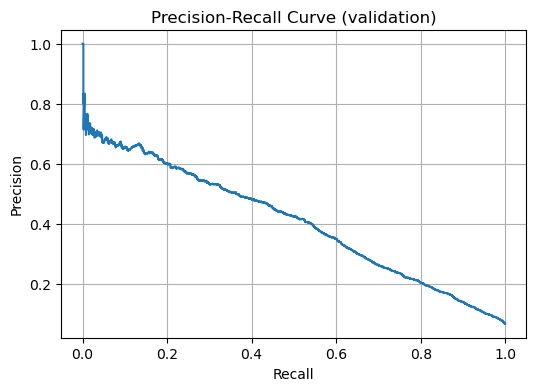

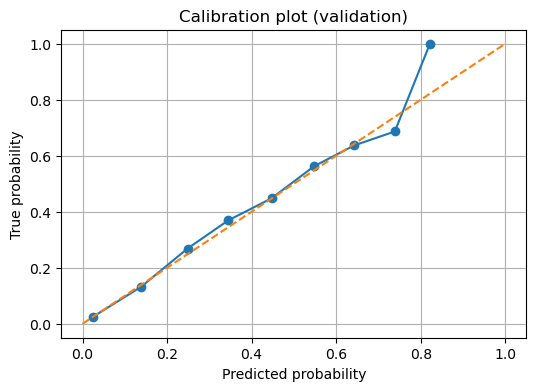

In [10]:
# -------------------------
# 7) Evaluation helper (inline)
# -------------------------
def evaluate_probs(y_true, y_proba, threshold=0.5, show_plots=True, title_suffix=""):
    y_pred = (y_proba >= threshold).astype(int)
    print("Classification report (threshold {:.2f}):\n".format(threshold))
    print(classification_report(y_true, y_pred))
    roc = roc_auc_score(y_true, y_proba)
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall, precision)
    brier = brier_score_loss(y_true, y_proba)
    print(f"ROC AUC {title_suffix}: {roc:.4f}")
    print(f"PR AUC {title_suffix}: {pr_auc:.4f}")
    print(f"Brier score {title_suffix}: {brier:.4f}")
    if show_plots:
        # Precision-Recall
        plt.figure(figsize=(6,4))
        plt.plot(recall, precision)
        plt.xlabel("Recall"); plt.ylabel("Precision")
        plt.title("Precision-Recall Curve " + title_suffix)
        plt.grid(True); plt.show()
        # Calibration plot
        prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=10)
        plt.figure(figsize=(6,4))
        plt.plot(prob_pred, prob_true, marker="o")
        plt.plot([0,1],[0,1],"--")
        plt.xlabel("Predicted probability"); plt.ylabel("True probability")
        plt.title("Calibration plot " + title_suffix)
        plt.grid(True); plt.show()

# Evaluate on validation
print("Validation evaluation (before calibration):")
y_val_proba = bst.predict(X_val_t, num_iteration=bst.best_iteration)
evaluate_probs(y_val, y_val_proba, threshold=0.5, title_suffix="(validation)")

Calibrating probabilities (Platt scaling) using validation set...

Test evaluation (calibrated):
Classification report (threshold 0.50):

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     27995
           1       0.57      0.23      0.33      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.61      0.65     30000
weighted avg       0.92      0.94      0.92     30000

ROC AUC (test): 0.8655
PR AUC (test): 0.4041
Brier score (test): 0.0506


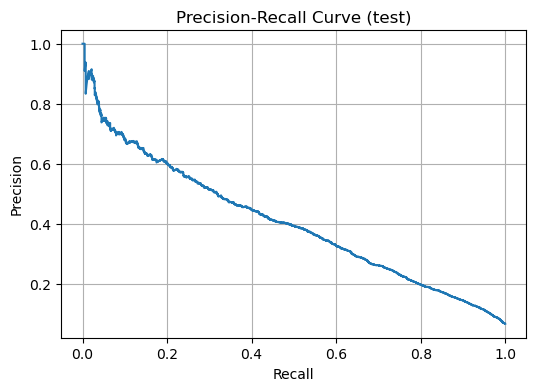

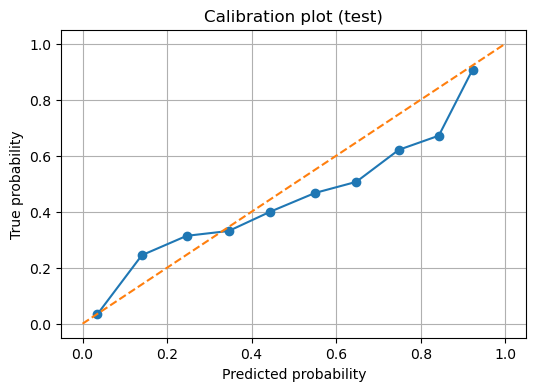

In [12]:
# -------------------------
# 8) Calibrate probabilities (Platt scaling) using validation set
# -------------------------
print("Calibrating probabilities (Platt scaling) using validation set...")

from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV

# Create an sklearn wrapper using the number of iterations the booster used
# (bst.best_iteration may be None if you used the sklearn wrapper earlier; then pick a reasonable n_estimators)
n_iter = bst.best_iteration if getattr(bst, "best_iteration", None) is not None else 100

lgb_wrapper = LGBMClassifier(
    n_estimators=n_iter,
    learning_rate=params["learning_rate"],
    num_leaves=params["num_leaves"],
    max_depth=params["max_depth"],
    random_state=42,
    n_jobs=-1
)

# Fit the wrapper on the transformed training data
lgb_wrapper.fit(X_train_t, y_train)

# Instantiate CalibratedClassifierCV with the correct keyword 'estimator' and indicate the estimator is prefit
calibrator = CalibratedClassifierCV(estimator=lgb_wrapper, method="sigmoid", cv="prefit")

# Fit the calibrator on the validation set (transformed)
calibrator.fit(X_val_t, y_val)

# Evaluate calibrated model on test set
print("\nTest evaluation (calibrated):")
y_test_proba = calibrator.predict_proba(X_test_t)[:, 1]
evaluate_probs(y_test, y_test_proba, threshold=0.5, title_suffix="(test)")


In [13]:
# -------------------------
# 9) Save preprocessor + calibrated model
# -------------------------
print("Saving preprocessor + calibrated model...")
MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({"preprocessor": preprocessor, "calibrator": calibrator}, MODEL_OUT)
print("Saved ->", MODEL_OUT)
print()

Saving preprocessor + calibrated model...
Saved -> models\give_credit_lgbm.joblib



Running SHAP summary (sampled 200 rows)... This may open a plot.


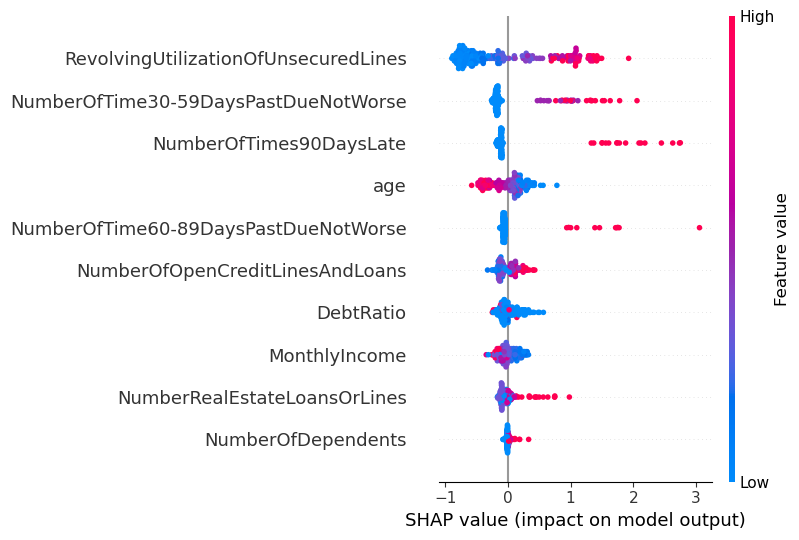

All done.


In [14]:
# -------------------------
# 10) SHAP explainability (sampled)
# -------------------------
print("Running SHAP summary (sampled 200 rows)... This may open a plot.")
try:
    import shap
    sample_n = min(200, X_test_t.shape[0])
    idx = np.random.choice(X_test_t.shape[0], size=sample_n, replace=False)
    X_shap = X_test_t[idx]
    # shap expects the booster object (tree) — use the wrapper's fitted estimator (lgb_wrapper)
    explainer = shap.Explainer(lgb_wrapper)
    shap_values = explainer(X_shap)
    feature_names = numeric_cols
    shap.summary_plot(shap_values, features=X_shap, feature_names=feature_names, max_display=10)
except Exception as e:
    print("SHAP skipped (error):", e)

print("All done.")